# MSE 5720 Assignment 1  
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

---

## Introduction  

This homework focuses on the calculation of various properties of **calcium titanate (CaTiO₃)** using *density functional theory (DFT)*.  
CaTiO₃ is a **perovskite-type oxide** with wide applications in electronic and energy-related fields, making it an interesting subject for first-principles study.  

- **Exercise 1**  
  The convergence behavior of the total energy with respect to **plane-wave cutoff energy** and **k-point sampling** is examined.  
  Since an infinite plane-wave basis set cannot be achieved in practice, a finite cutoff must be chosen.  
  A higher cutoff and denser k-point grid improve accuracy but also increase computational cost, so an optimal balance is desired.  

- **Exercise 2**  
  The equilibrium lattice constant of CaTiO₃ is obtained by **fitting the energy–volume curve** and through **structural optimization** using *Quantum ESPRESSO*.  
  The calculated results are then compared with benchmark values reported in the literature.  

- **Exercise 3**  
  The **bulk modulus** is determined from the **equation of state** by fitting the energy–volume relation.  
  The computed values are discussed in relation to the literature data, with attention to the accuracy of the fitting procedure.  

- **Exercise 4**  
  The effect of **different pseudopotentials** on the optimized lattice constant is evaluated and compared with the results from Exercise 2.  
  Since pseudopotential choice can influence the DFT results, experimental data are referenced to assess the reliability of the calculations.  


In [29]:
import os
import re
import requests
import matplotlib.pyplot as plt

**Exercise 1a**

Set the calculation type to scf and calculate the total energy in a range from 20 – 100 Ry in increments of 10 Ry. A good absolute energy is converged when the energy difference between a given cutoff and the next highest cutoff is less than around 5 meV/formula unit. Tabulate and make a graph of the results.

In [30]:
base_path = "HW1/Q1/A"
cutoffs = list(range(20, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"! *total energy *= *([-+]?\d*\.\d+) Ry")

[20, 30, 40, 50, 60, 70, 80, 90, 100]


In [42]:
for cutoff in cutoffs:

    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q1/A/cto_{cutoff}/CTO.out"
    
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy} Ry")
    else:
        print(f"No energy found in {url}")
        energies.append(None)

Cutoff 20: Energy = -290.92254356 Ry
Cutoff 30: Energy = -291.66701012 Ry
Cutoff 40: Energy = -291.69406566 Ry
Cutoff 50: Energy = -291.69522418 Ry
Cutoff 60: Energy = -291.69650898 Ry
Cutoff 70: Energy = -291.69676334 Ry
Cutoff 80: Energy = -291.69726827 Ry
Cutoff 90: Energy = -291.6978959 Ry
Cutoff 100: Energy = -291.69824766 Ry


ValueError: x and y must have same first dimension, but have shapes (9,) and (20,)

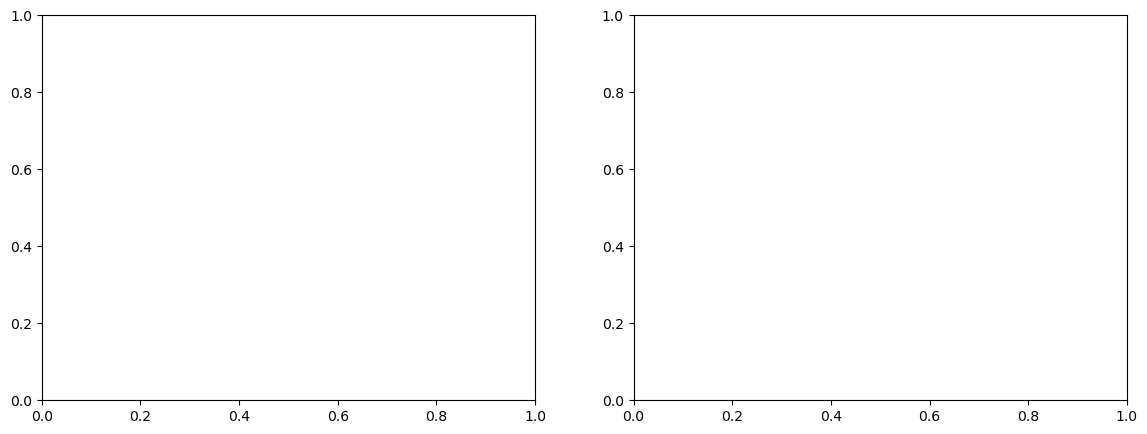

In [ ]:
min_energy = min([e for e in energies if e is not None])
delta_energies = [e - min_energy for e in energies]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, marker='o')
axes[0].set_xlabel("Plane wave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, marker='o')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Plane wave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-5, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

From the right sub figure it can be deduced that the planewave cutoff is 40 Ry.

**Exercise 1b**

Keep the calculation type as scf and set the plane wave cutoff to the converged value you found in the previous exercise; keep the plane wave cutoff (and other variables) constant while testing k-point convergence. There are some “cross effects” in testing cutoff and k-points separately, however we assume these are small. Calculate the total energy for a series of **M**✖**M**✖**M**
 grids, where M = 2, 3, 4, 5, 6 and 8. Record the total energy for each value of M.

In [33]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [34]:
energy_pattern = re.compile(r"! *total energy *= *([-+]?\d*\.\d+) Ry")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [35]:
for k in ks:
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q1/B/cto_k{k}/CTO.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {url}")
        energies.append(None)
        num_kpoints.append(None)
        continue

    content = response.text

    match_energy = energy_pattern.search(content)
    if match_energy:
        energy = float(match_energy.group(1))
    else:
        print(f"No energy found in {url}")
        energy = None
    energies.append(energy)

    match_k = kpoint_pattern.search(content)
    if match_k:
        nk = int(match_k.group(1))
    else:
        nk = None
    num_kpoints.append(nk)

    print(f"k={k}, number of k points={nk}, Energy={energy} Ry")

k=2, number of k points=4, Energy=-291.69522418 Ry
k=3, number of k points=4, Energy=-291.74232039 Ry
k=4, number of k points=10, Energy=-291.74866628 Ry
k=5, number of k points=10, Energy=-291.74976846 Ry
k=6, number of k points=20, Energy=-291.74996687 Ry
k=7, number of k points=20, Energy=-291.7500056 Ry
k=8, number of k points=35, Energy=-291.75001828 Ry
k=9, number of k points=35, Energy=-291.75002061 Ry
k=10, number of k points=56, Energy=-291.75002063 Ry
k=11, number of k points=56, Energy=-291.75002018 Ry
k=12, number of k points=84, Energy=-291.75002016 Ry


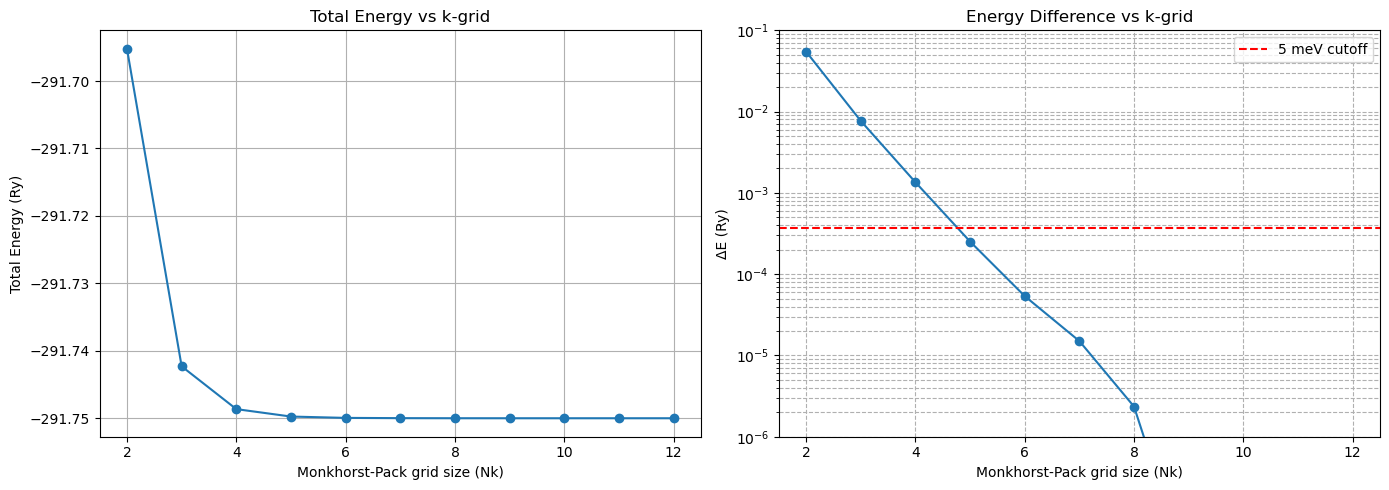

In [40]:
min_energy = min([e for e in energies if e is not None])
delta_energies = [e - min_energy if e is not None else None for e in energies]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(ks, energies, marker='o')
axes[0].set_xlabel("Monkhorst-Pack grid size (Nk)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_energies, marker='o')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")
axes[1].set_xlabel("Monkhorst-Pack grid size (Nk)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()